# 🏦 Home Credit Default Risk — Розвідувальний аналіз даних (EDA)

**Мета:** Дослідити структуру даних, виявити закономірності та підготуватись до побудови моделі кредитного скорингу.

**Дані:** 8 таблиць у PostgreSQL — заявки на кредит, кредитне бюро, попередні заявки, баланси карток тощо.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Створити директорію для графіків (обов'язково перед першим savefig)
PLOTS_DIR = os.path.join('..', 'models', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f'📁 Директорія графіків: {os.path.abspath(PLOTS_DIR)}')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.db import load_local, list_tables, get_table_info

# Стиль графіків
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')
sns.set_style('whitegrid')
print('✅ Бібліотеки завантажено')

📁 Директорія графіків: C:\Home Credit Default Risk\Home-Credit-Default-Risk\models\plots
✅ Бібліотеки завантажено


## 1. Огляд бази даних

In [2]:
tables = list_tables()
print(f'Таблиці в базі даних ({len(tables)} шт.):')
for t in tables:
    print(f'  📋 {t}')

Таблиці в базі даних (8 шт.):
  📋 application_test
  📋 application_train
  📋 bureau
  📋 bureau_balance
  📋 credit_card_balance
  📋 installments_payments
  📋 pos_cash_balance
  📋 previous_application


In [3]:
# Завантаження основної таблиці
app = load_local('application_train')
app.columns = [c.lower() for c in app.columns]
print(f'Розмір: {app.shape[0]:,} рядків × {app.shape[1]} колонок')
app.head(3)

✅ 'application_train' з parquet: 307,511 рядків, 122 колонок
Розмір: 307,511 рядків × 122 колонок


,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,100281,0,Cash loans,F,N,Y,1,112500.0,675000.0,21906.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
1,100282,1,Revolving loans,F,Y,Y,0,73341.0,135000.0,6750.0,...,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,100283,0,Cash loans,F,N,Y,0,135000.0,747000.0,38268.0,...,0,0,0,0,0.0,0.0,1.0,0.0,0.0,1.0


In [4]:
# Типи даних
dtype_counts = app.dtypes.value_counts()
print('Типи колонок:')
for dtype, count in dtype_counts.items():
    print(f'  {dtype}: {count}')

print(f'\nЧислових: {app.select_dtypes(include="number").shape[1]}')
print(f'Категоріальних: {app.select_dtypes(include="object").shape[1]}')

Типи колонок:
  float64: 65
  int64: 41
  str: 16

Числових: 106
Категоріальних: 16


## 2. Цільова змінна (TARGET)

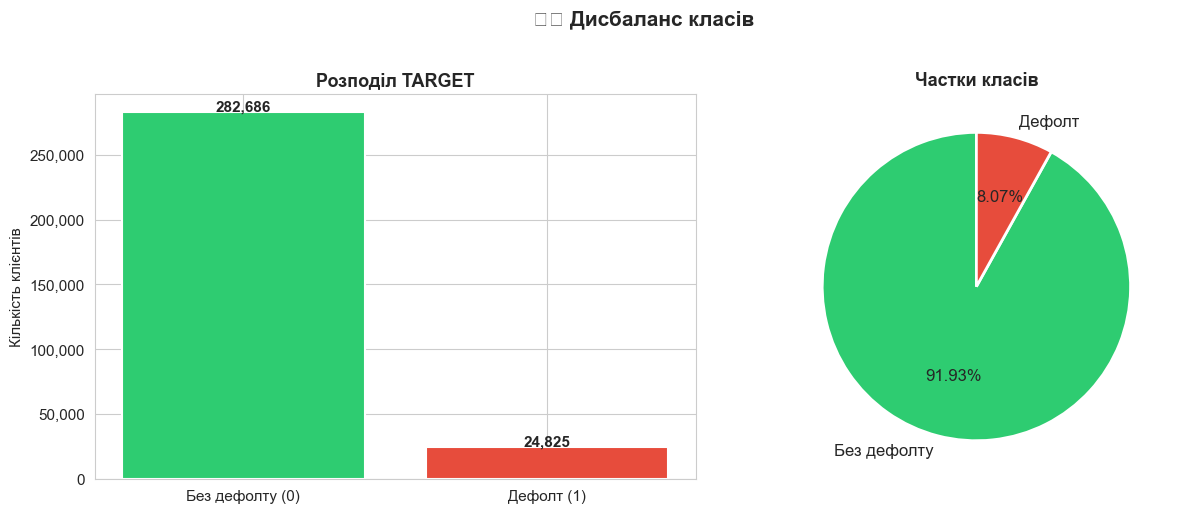


Рівень дефолту: 8.07%
Дисбаланс класів: 1:11.4


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Countplot
counts = app['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Без дефолту (0)', 'Дефолт (1)'], counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Розподіл TARGET', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Кількість клієнтів')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie chart
axes[1].pie(counts.values, labels=['Без дефолту', 'Дефолт'],
            colors=colors, autopct='%1.2f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Частки класів', fontsize=13, fontweight='bold')

plt.suptitle('⚖️ Дисбаланс класів', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/plots/target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

default_rate = app['target'].mean()
print(f'\nРівень дефолту: {default_rate:.2%}')
print(f'Дисбаланс класів: 1:{counts[0]/counts[1]:.1f}')

## 3. Пропущені значення

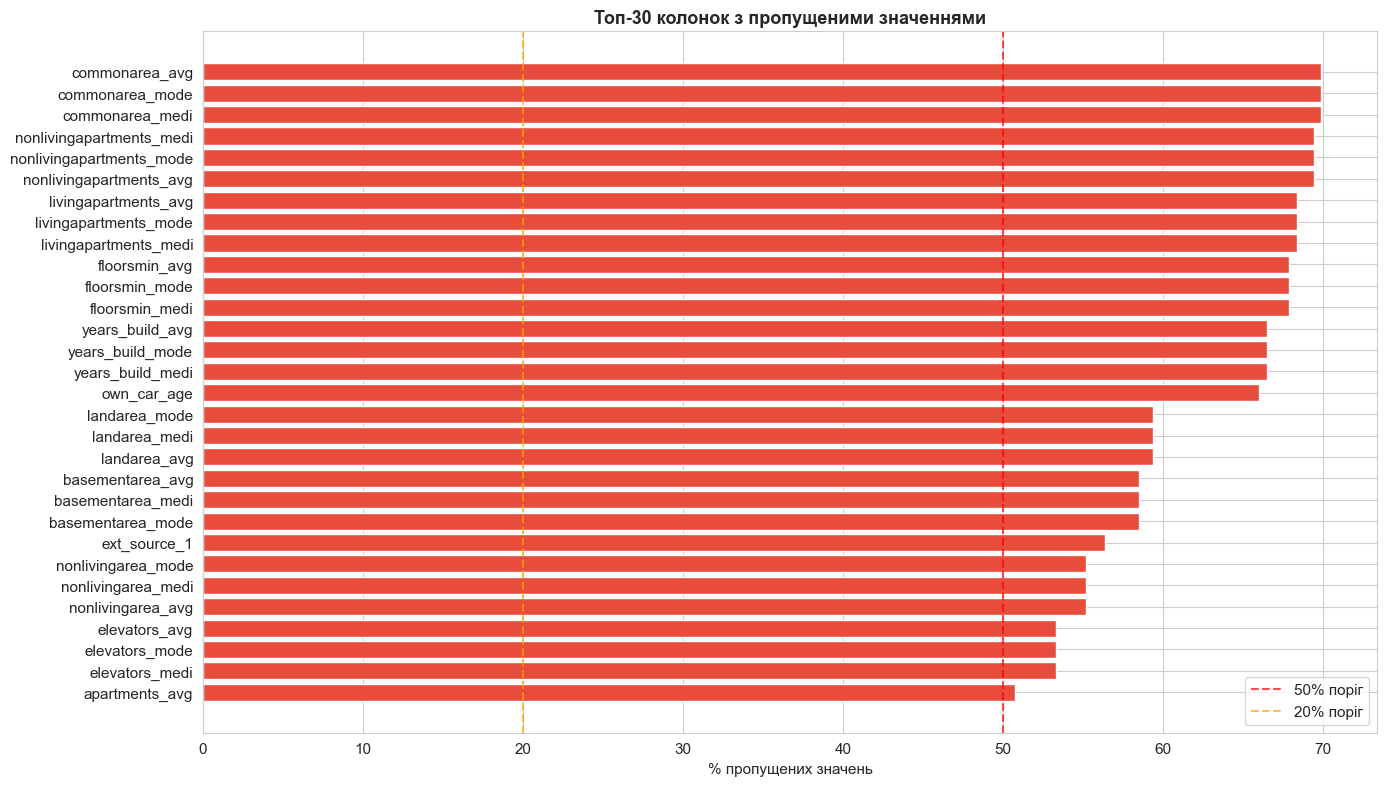

Колонок без пропусків: 61
Колонок з >50% пропусків: 38
Колонок з >20% пропусків: 45


In [6]:
# Топ-30 колонок з пропусками
missing = app.isnull().sum()
missing_pct = (missing / len(app) * 100).sort_values(ascending=False)
missing_top = missing_pct[missing_pct > 0].head(30)

fig, ax = plt.subplots(figsize=(14, 8))
colors_miss = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#3498db' for x in missing_top.values]
bars = ax.barh(missing_top.index[::-1], missing_top.values[::-1], color=colors_miss[::-1])
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='50% поріг')
ax.axvline(20, color='orange', linestyle='--', alpha=0.7, label='20% поріг')
ax.set_xlabel('% пропущених значень')
ax.set_title('Топ-30 колонок з пропущеними значеннями', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../models/plots/missing_values.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Колонок без пропусків: {(missing == 0).sum()}')
print(f'Колонок з >50% пропусків: {(missing_pct > 50).sum()}')
print(f'Колонок з >20% пропусків: {(missing_pct > 20).sum()}')

## 4. Числові змінні

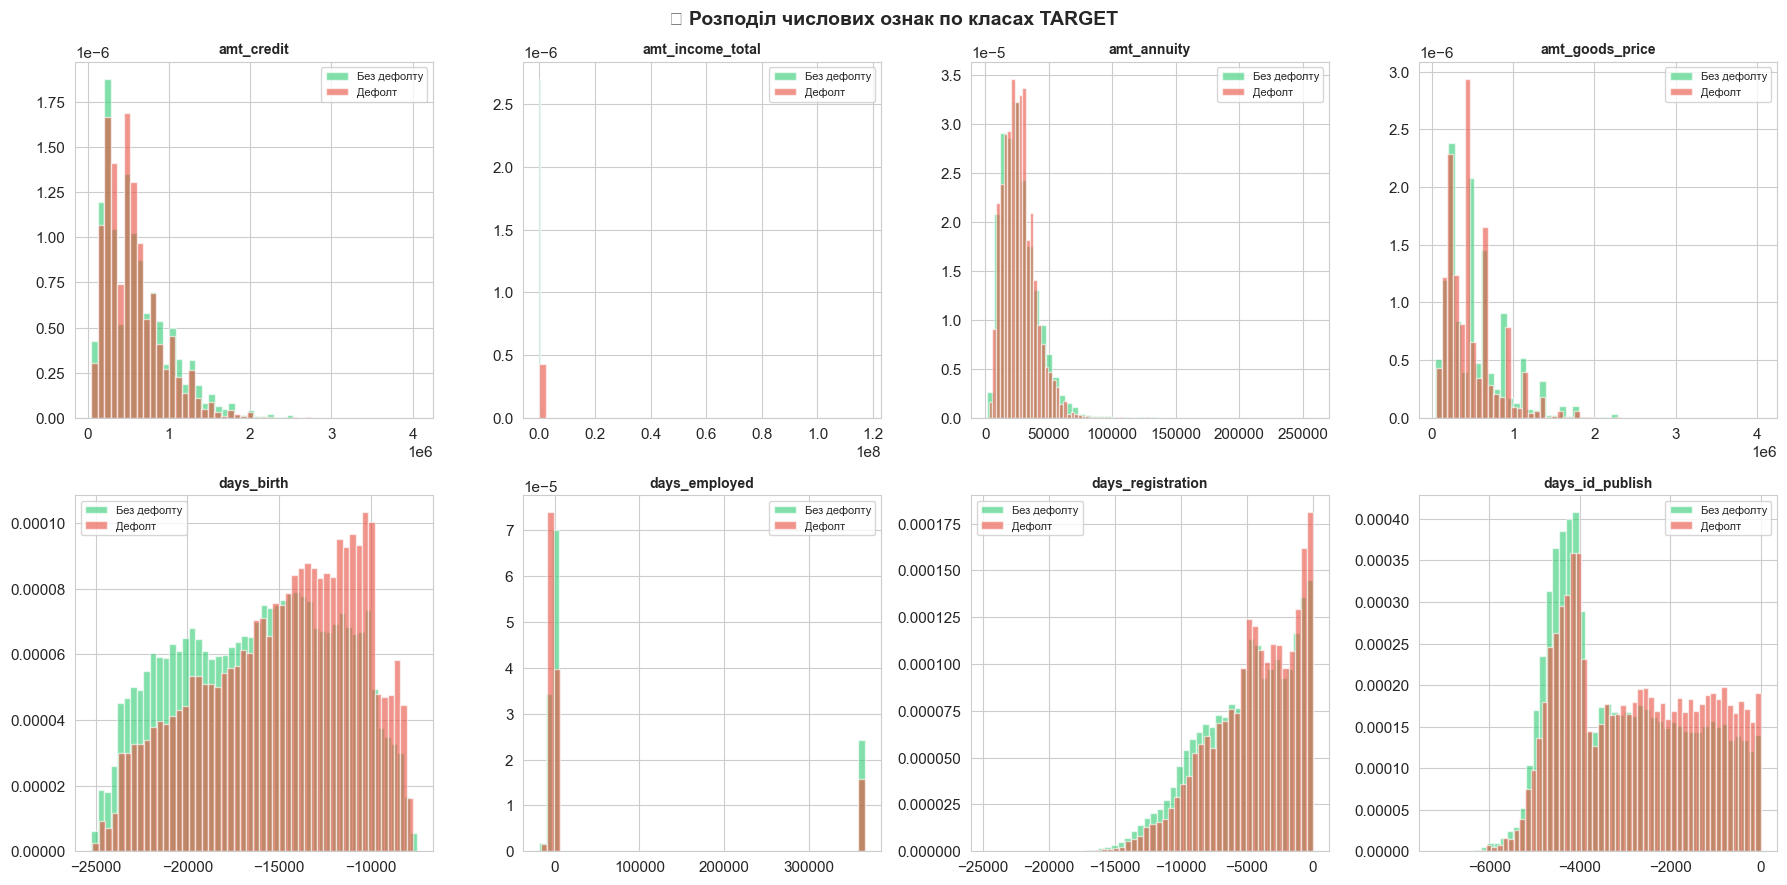

In [7]:
# Ключові числові ознаки
key_num = ['amt_credit', 'amt_income_total', 'amt_annuity', 'amt_goods_price',
           'days_birth', 'days_employed', 'days_registration', 'days_id_publish']
key_num = [c for c in key_num if c in app.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(key_num):
    data_0 = app[app['target'] == 0][col].dropna()
    data_1 = app[app['target'] == 1][col].dropna()
    axes[i].hist(data_0, bins=50, alpha=0.6, color='#2ecc71', label='Без дефолту', density=True)
    axes[i].hist(data_1, bins=50, alpha=0.6, color='#e74c3c', label='Дефолт', density=True)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('📊 Розподіл числових ознак по класах TARGET', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/numeric_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

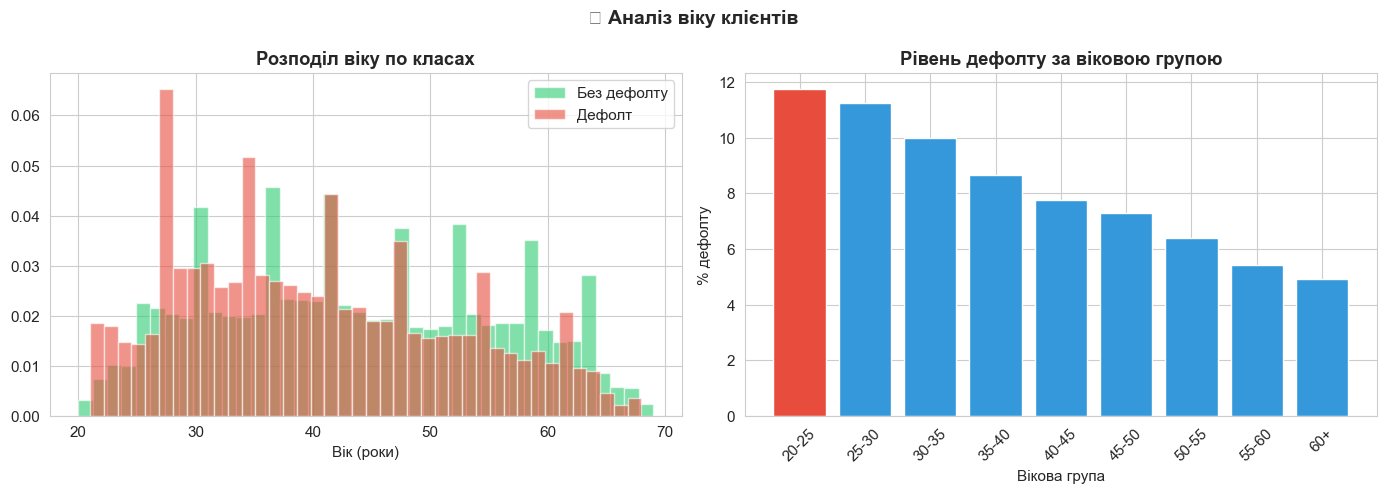

Вікова група з найбільшим ризиком: 20-25


In [8]:
# Аналіз віку (days_birth -> age)
app['age_years'] = (-app['days_birth'] / 365).astype(int)
app['age_group'] = pd.cut(app['age_years'], bins=[20, 25, 30, 35, 40, 45, 50, 55, 60, 70],
                          labels=['20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','60+'])

age_default = app.groupby('age_group', observed=True)['target'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(app[app['target']==0]['age_years'], bins=40, alpha=0.6, color='#2ecc71', label='Без дефолту', density=True)
axes[0].hist(app[app['target']==1]['age_years'], bins=40, alpha=0.6, color='#e74c3c', label='Дефолт', density=True)
axes[0].set_title('Розподіл віку по класах', fontweight='bold')
axes[0].set_xlabel('Вік (роки)')
axes[0].legend()

color_bars = ['#e74c3c' if v == age_default['target'].max() else '#3498db' for v in age_default['target']]
bars = axes[1].bar(age_default['age_group'].astype(str), age_default['target'] * 100, color=color_bars)
axes[1].set_title('Рівень дефолту за віковою групою', fontweight='bold')
axes[1].set_xlabel('Вікова група')
axes[1].set_ylabel('% дефолту')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('👥 Аналіз віку клієнтів', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/age_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('Вікова група з найбільшим ризиком:', age_default.loc[age_default['target'].idxmax(), 'age_group'])

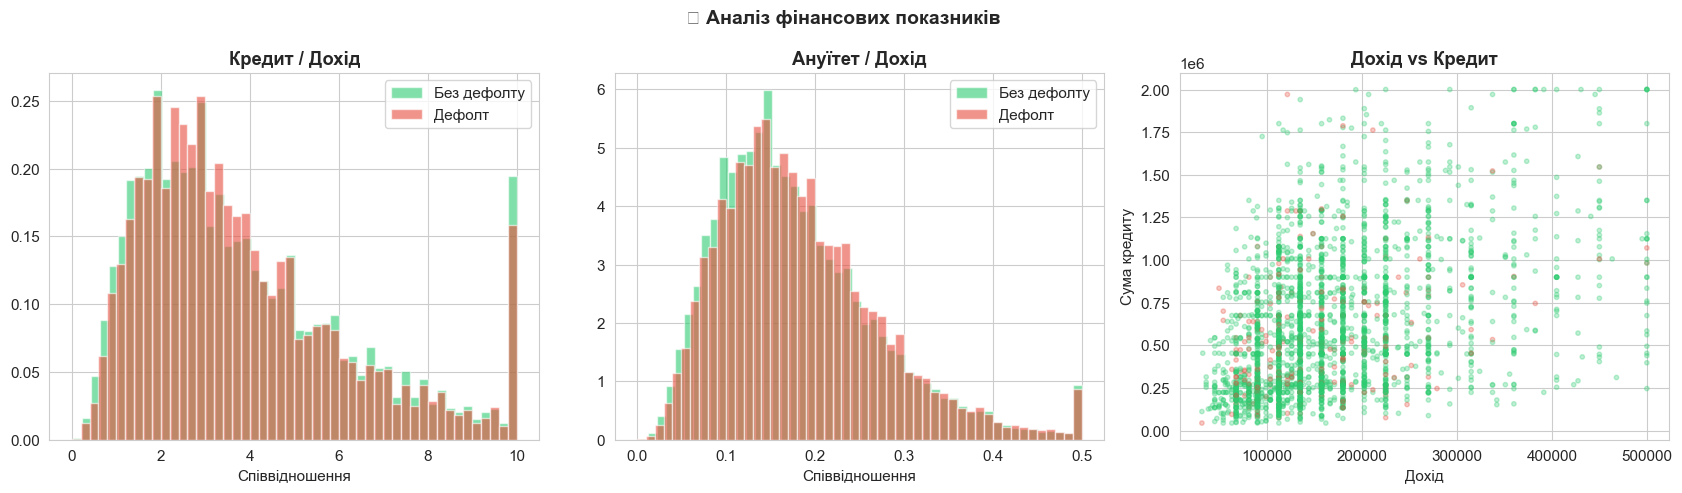

In [9]:
# Аналіз доходу та кредиту
app['credit_income_ratio'] = app['amt_credit'] / (app['amt_income_total'] + 1)
app['annuity_income_ratio'] = app['amt_annuity'] / (app['amt_income_total'] + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Credit/Income ratio
for target_val, color, label in [(0, '#2ecc71', 'Без дефолту'), (1, '#e74c3c', 'Дефолт')]:
    data = app[app['target'] == target_val]['credit_income_ratio'].clip(0, 10)
    axes[0].hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title('Кредит / Дохід', fontweight='bold')
axes[0].set_xlabel('Співвідношення')
axes[0].legend()

# Annuity/Income ratio
for target_val, color, label in [(0, '#2ecc71', 'Без дефолту'), (1, '#e74c3c', 'Дефолт')]:
    data = app[app['target'] == target_val]['annuity_income_ratio'].clip(0, 0.5)
    axes[1].hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[1].set_title('Ануїтет / Дохід', fontweight='bold')
axes[1].set_xlabel('Співвідношення')
axes[1].legend()

# Scatter: credit vs income (sample)
sample = app.sample(3000, random_state=42)
colors_scatter = sample['target'].map({0: '#2ecc71', 1: '#e74c3c'})
axes[2].scatter(sample['amt_income_total'].clip(0, 500000),
                sample['amt_credit'].clip(0, 2000000),
                c=colors_scatter, alpha=0.3, s=10)
axes[2].set_title('Дохід vs Кредит', fontweight='bold')
axes[2].set_xlabel('Дохід')
axes[2].set_ylabel('Сума кредиту')

plt.suptitle('💰 Аналіз фінансових показників', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/financial_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Категоріальні змінні

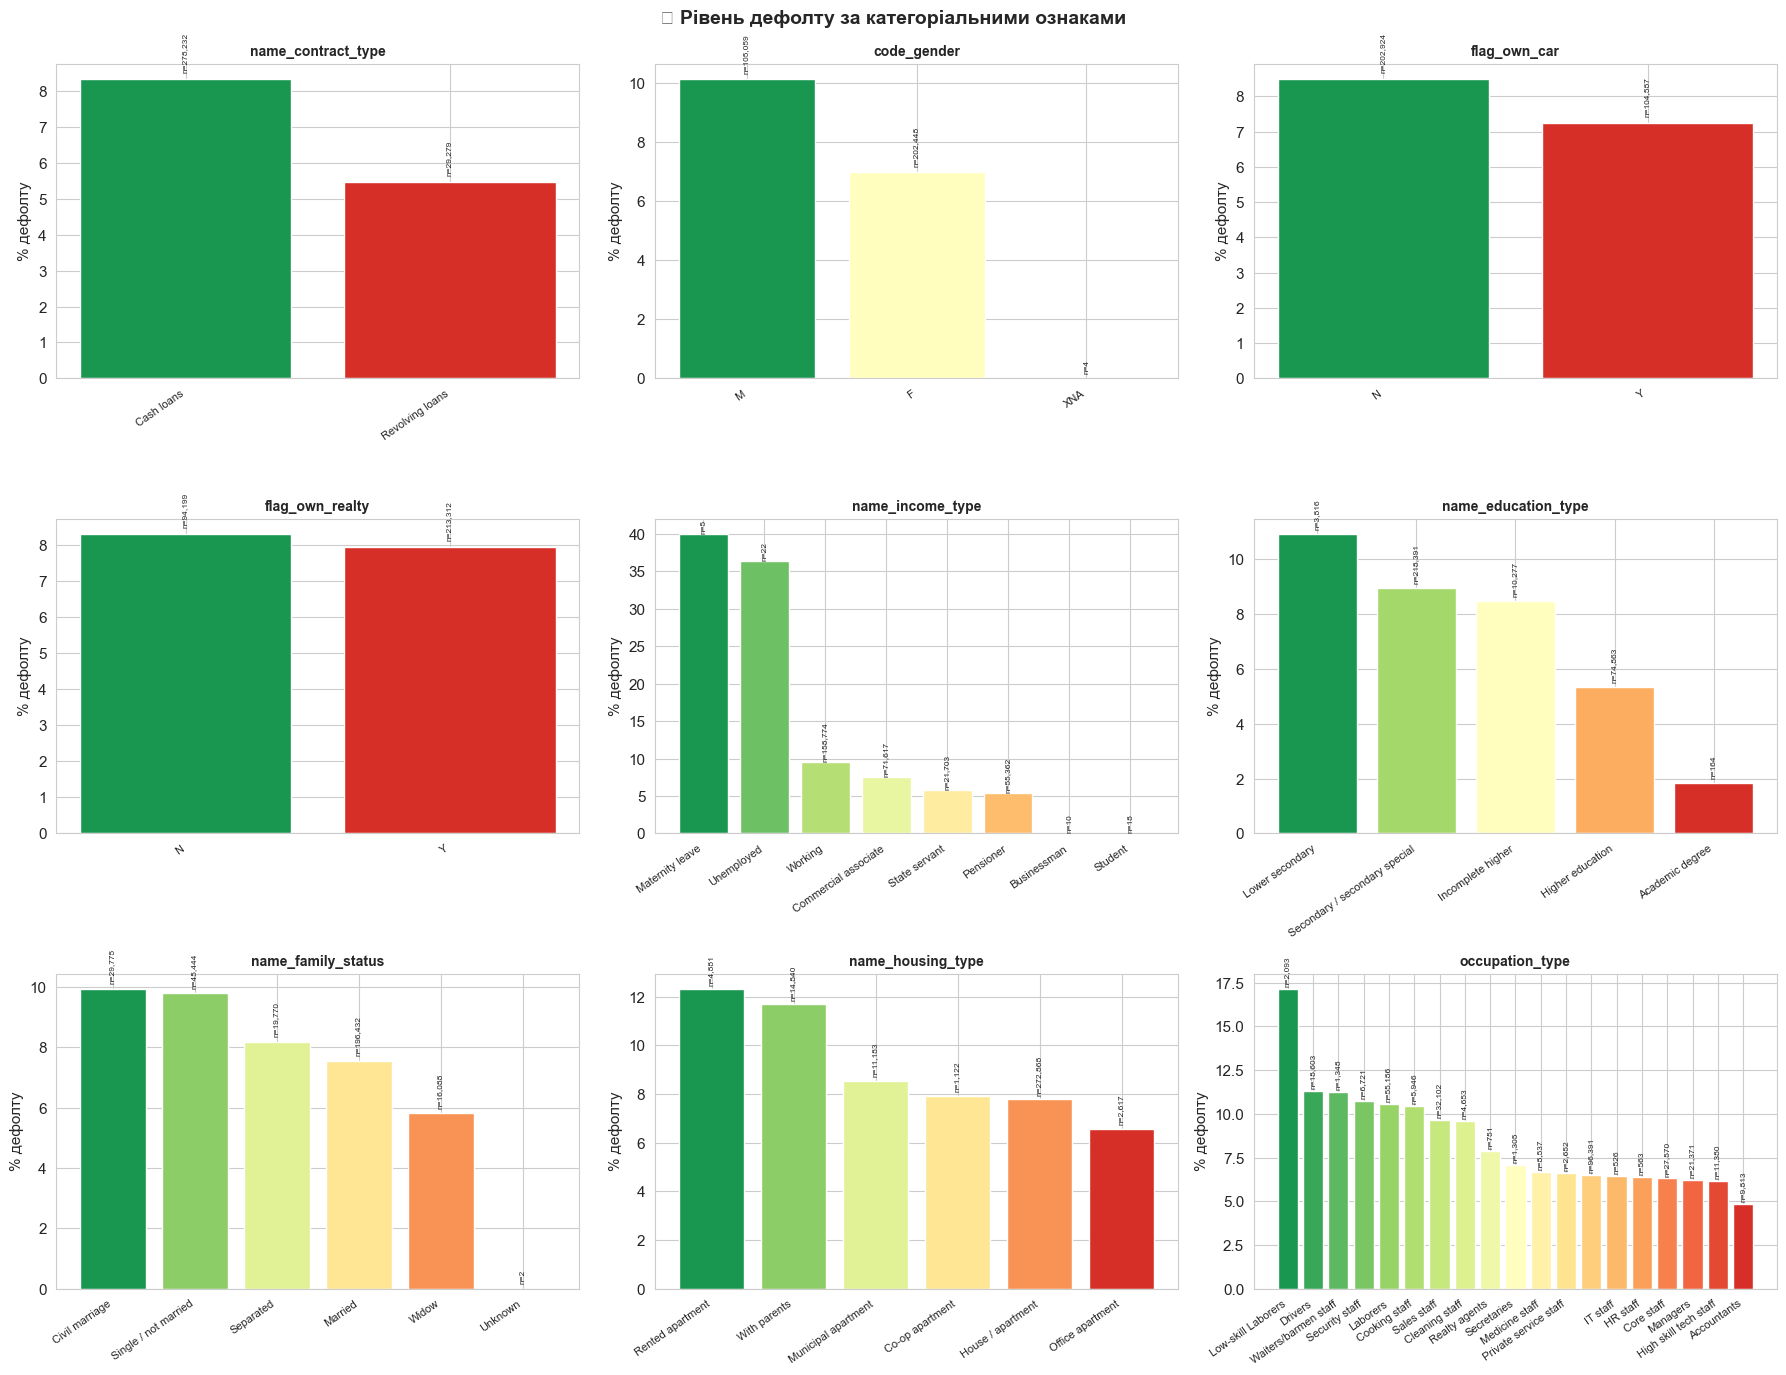

In [10]:
cat_cols = ['name_contract_type', 'code_gender', 'flag_own_car', 'flag_own_realty',
            'name_income_type', 'name_education_type', 'name_family_status',
            'name_housing_type', 'occupation_type']
cat_cols = [c for c in cat_cols if c in app.columns]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate_cat = app.groupby(col)['target'].mean().sort_values(ascending=False)
    count_cat = app[col].value_counts()

    colors_cat = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(default_rate_cat)))
    bars = axes[i].bar(range(len(default_rate_cat)), default_rate_cat.values * 100, color=colors_cat)
    axes[i].set_xticks(range(len(default_rate_cat)))
    axes[i].set_xticklabels(default_rate_cat.index, rotation=35, ha='right', fontsize=8)
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('% дефолту')

    # Annotate with counts
    for j, (bar, cat) in enumerate(zip(bars, default_rate_cat.index)):
        n = count_cat.get(cat, 0)
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'n={n:,}', ha='center', fontsize=6, rotation=90)

plt.suptitle('📊 Рівень дефолту за категоріальними ознаками', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/categorical_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

In [11]:
# Детальний аналіз статі
gender_stats = app[app['code_gender'] != 'XNA'].groupby('code_gender').agg(
    count=('target', 'count'),
    default_rate=('target', 'mean'),
    avg_income=('amt_income_total', 'mean'),
    avg_credit=('amt_credit', 'mean'),
    avg_age=('age_years', 'mean')
).round(2)
print('📊 Статистика за статтю:')
print(gender_stats.to_string())

📊 Статистика за статтю:
              count  default_rate  avg_income  avg_credit  avg_age
code_gender                                                       
F            202448          0.07   156032.31   592766.72    44.71
M            105059          0.10   193396.48   611095.20    40.98


## 6. Кореляційний аналіз

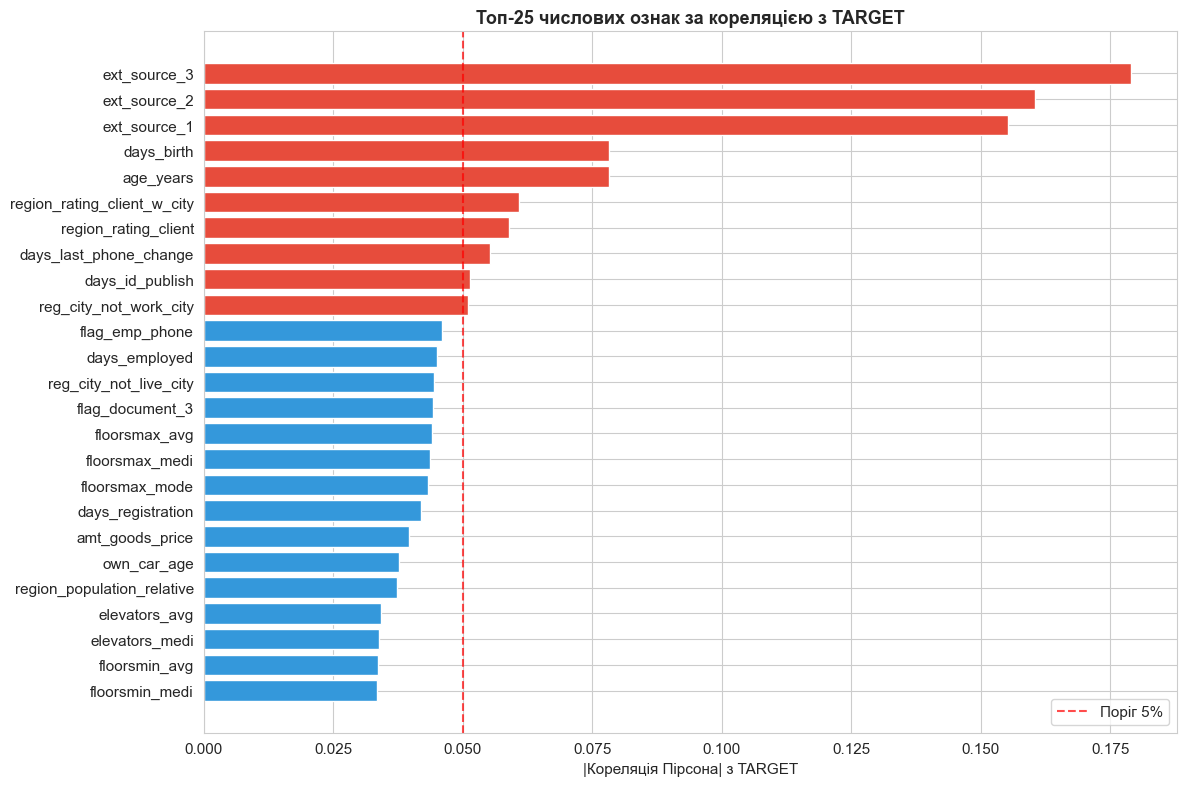

Топ-10 ознак:
ext_source_3                   0.178919
ext_source_2                   0.160472
ext_source_1                   0.155317
days_birth                     0.078239
age_years                      0.078234
region_rating_client_w_city    0.060893
region_rating_client           0.058899
days_last_phone_change         0.055218
days_id_publish                0.051457
reg_city_not_work_city         0.050994


In [12]:
# Топ кореляцій з TARGET
num_cols_corr = app.select_dtypes(include='number').columns.tolist()
corr_with_target = app[num_cols_corr].corr()['target'].drop('target').abs().sort_values(ascending=False)

top_corr = corr_with_target.head(25)

fig, ax = plt.subplots(figsize=(12, 8))
colors_corr = ['#e74c3c' if v > 0.05 else '#3498db' for v in top_corr.values]
bars = ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors_corr[::-1])
ax.axvline(0.05, color='red', linestyle='--', alpha=0.7, label='Поріг 5%')
ax.set_xlabel('|Кореляція Пірсона| з TARGET')
ax.set_title('Топ-25 числових ознак за кореляцією з TARGET', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../models/plots/correlation_target.png', bbox_inches='tight', dpi=150)
plt.show()

print('Топ-10 ознак:')
print(top_corr.head(10).to_string())

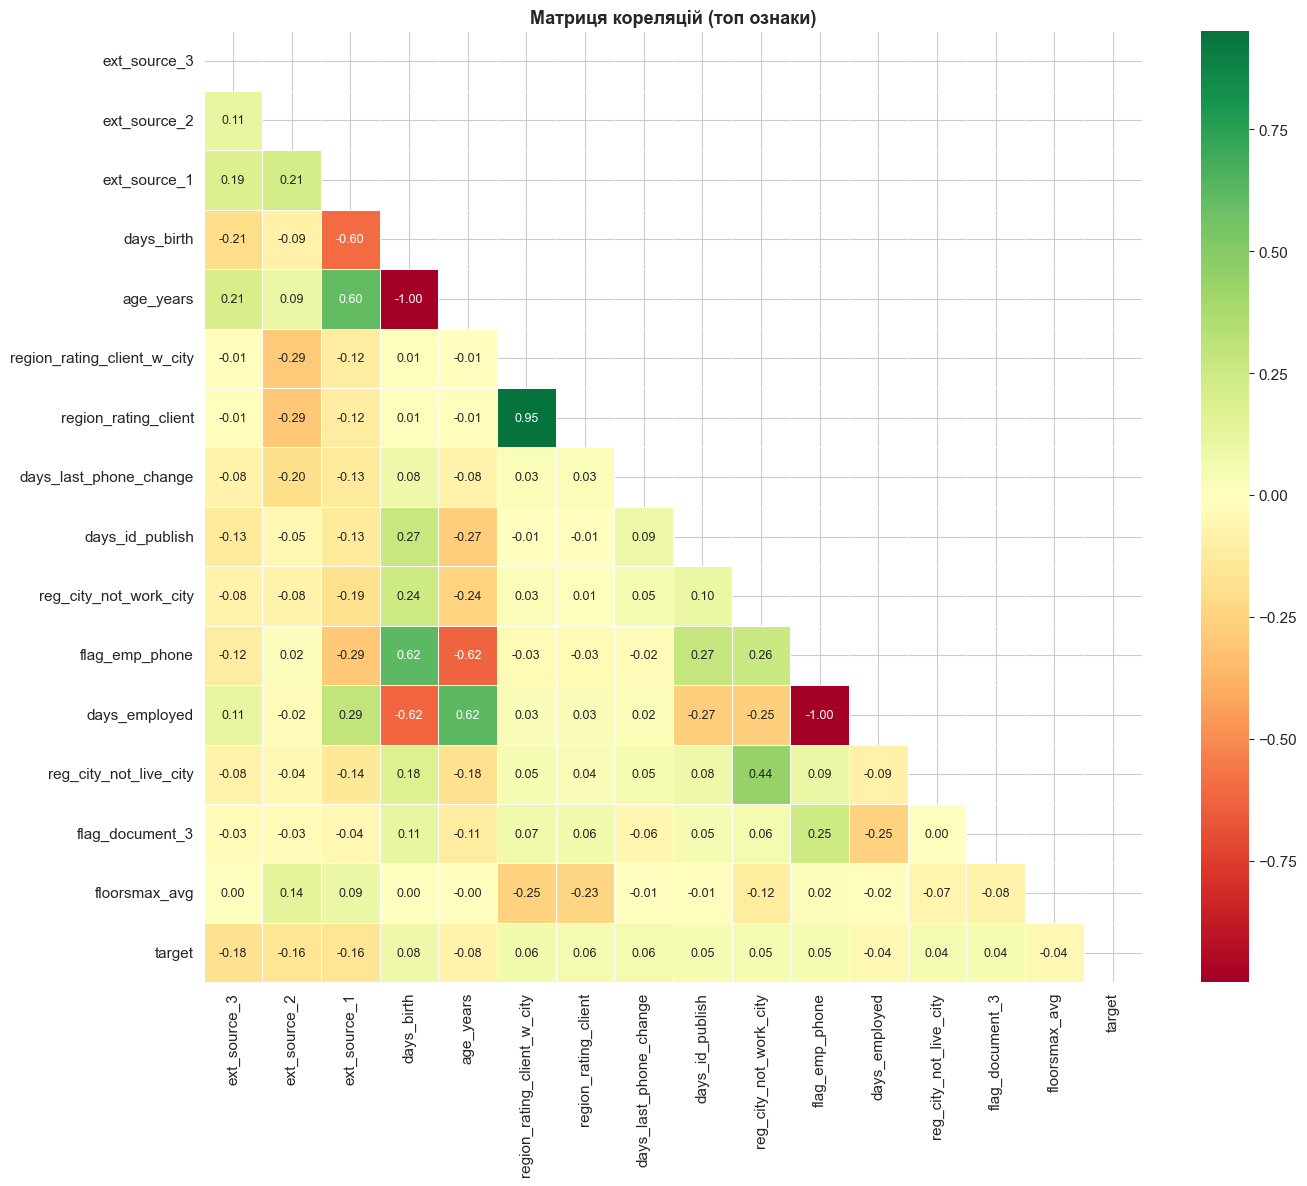

In [13]:
# Матриця кореляцій топ ознак
top_features = top_corr.head(15).index.tolist() + ['target']
corr_matrix = app[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Матриця кореляцій (топ ознаки)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Аналіз зайнятості

Безробітні / пенсіонери (days_employed=365243):
  Кількість: 55,374 (18.0%)
  Рівень дефолту: {0: 0.0865997453765215, 1: 0.05399646043269404}


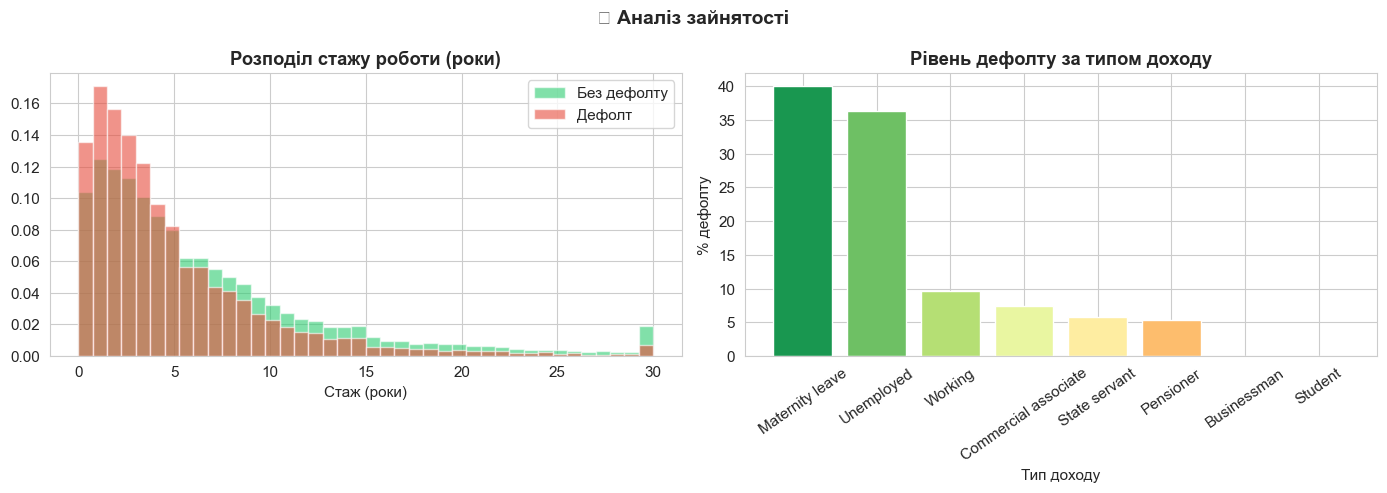

In [14]:
# days_employed: аномальне значення 365243 = пенсіонер/безробітний
app['employed_years'] = np.where(
    app['days_employed'] == 365243,
    np.nan,
    -app['days_employed'] / 365
)
app['is_unemployed'] = (app['days_employed'] == 365243).astype(int)

print('Безробітні / пенсіонери (days_employed=365243):')
print(f'  Кількість: {app["is_unemployed"].sum():,} ({app["is_unemployed"].mean():.1%})')
print(f'  Рівень дефолту: {app.groupby("is_unemployed")["target"].mean().to_dict()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

employed = app[app['employed_years'].notna()]
axes[0].hist(employed[employed['target']==0]['employed_years'].clip(0, 30),
             bins=40, alpha=0.6, color='#2ecc71', label='Без дефолту', density=True)
axes[0].hist(employed[employed['target']==1]['employed_years'].clip(0, 30),
             bins=40, alpha=0.6, color='#e74c3c', label='Дефолт', density=True)
axes[0].set_title('Розподіл стажу роботи (роки)', fontweight='bold')
axes[0].set_xlabel('Стаж (роки)')
axes[0].legend()

# Default rate by income type
income_default = app.groupby('name_income_type')['target'].mean().sort_values(ascending=False)
color_income = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(income_default)))
axes[1].bar(income_default.index, income_default.values * 100, color=color_income)
axes[1].set_title('Рівень дефолту за типом доходу', fontweight='bold')
axes[1].set_xlabel('Тип доходу')
axes[1].set_ylabel('% дефолту')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle('💼 Аналіз зайнятості', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/employment_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Зовнішні скорингові джерела (EXT_SOURCE)

Колонки EXT_SOURCE: ['ext_source_1', 'ext_source_2', 'ext_source_3']


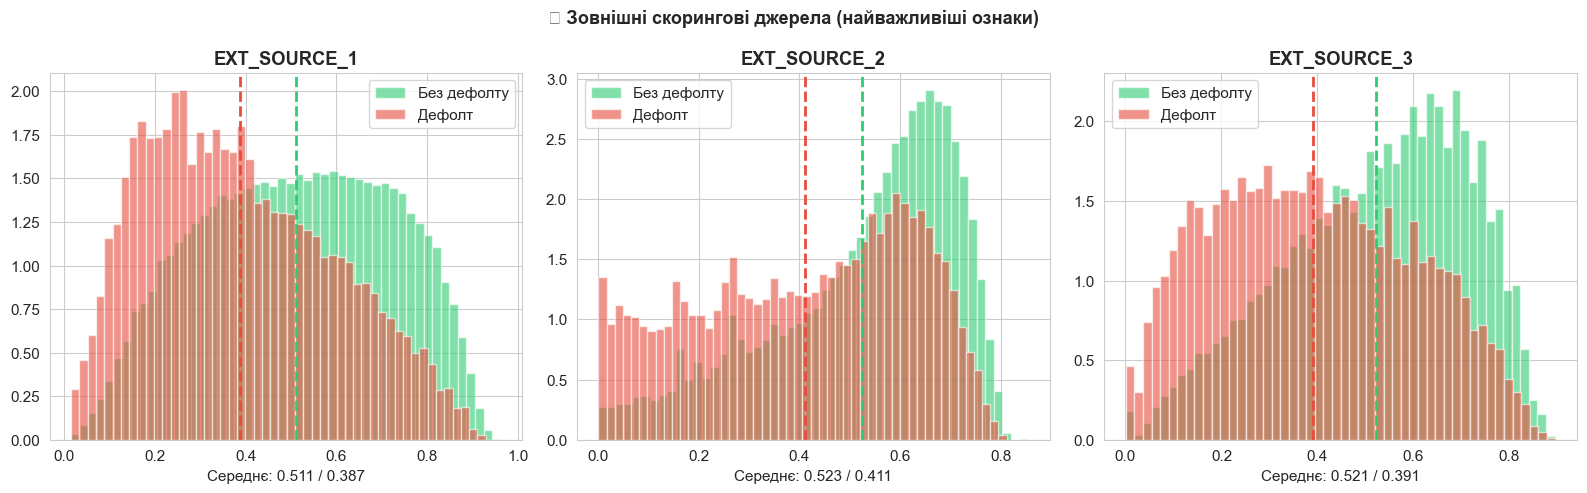

ext_source_1: кореляція з TARGET = -0.1553
ext_source_2: кореляція з TARGET = -0.1605
ext_source_3: кореляція з TARGET = -0.1789


In [15]:
ext_cols = [c for c in app.columns if 'ext_source' in c]
print(f'Колонки EXT_SOURCE: {ext_cols}')

fig, axes = plt.subplots(1, len(ext_cols), figsize=(16, 5))
if len(ext_cols) == 1:
    axes = [axes]

for i, col in enumerate(ext_cols):
    axes[i].hist(app[app['target']==0][col].dropna(), bins=50,
                 alpha=0.6, color='#2ecc71', label='Без дефолту', density=True)
    axes[i].hist(app[app['target']==1][col].dropna(), bins=50,
                 alpha=0.6, color='#e74c3c', label='Дефолт', density=True)
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].legend()

    # Stats
    mean_0 = app[app['target']==0][col].mean()
    mean_1 = app[app['target']==1][col].mean()
    axes[i].axvline(mean_0, color='#2ecc71', linestyle='--', linewidth=2)
    axes[i].axvline(mean_1, color='#e74c3c', linestyle='--', linewidth=2)
    axes[i].set_xlabel(f'Середнє: {mean_0:.3f} / {mean_1:.3f}')

plt.suptitle('🏦 Зовнішні скорингові джерела (найважливіші ознаки)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/ext_sources.png', bbox_inches='tight', dpi=150)
plt.show()

# Кореляції EXT_SOURCE з TARGET
for col in ext_cols:
    corr = app[[col, 'target']].dropna().corr().loc[col, 'target']
    print(f'{col}: кореляція з TARGET = {corr:.4f}')

## 9. Аналіз суміжних таблиць

✅ 'bureau' з parquet: 1,716,428 рядків, 17 колонок
Bureau: 1,716,428 рядків × 17 колонок
Унікальних клієнтів: 305,811
Середня кількість записів на клієнта: 5.6


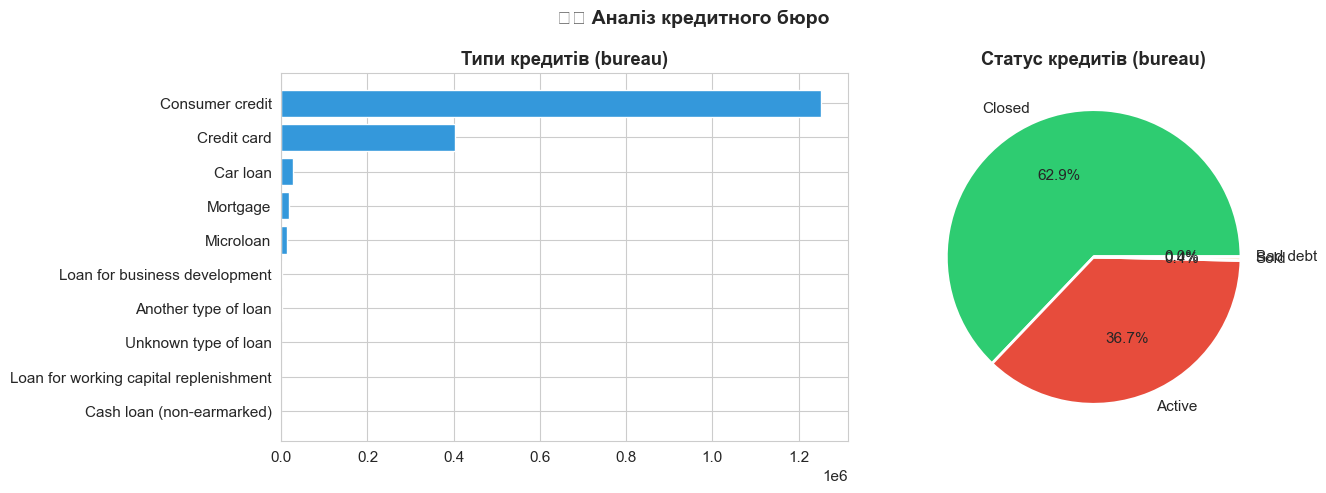

In [16]:
# Bureau - кредитна історія
bureau = load_local('bureau')
bureau.columns = [c.lower() for c in bureau.columns]

print(f'Bureau: {bureau.shape[0]:,} рядків × {bureau.shape[1]} колонок')
print(f'Унікальних клієнтів: {bureau["sk_id_curr"].nunique():,}')
print(f'Середня кількість записів на клієнта: {bureau.groupby("sk_id_curr").size().mean():.1f}')

# Типи кредитів
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

credit_type_counts = bureau['credit_type'].value_counts().head(10)
axes[0].barh(credit_type_counts.index[::-1], credit_type_counts.values[::-1], color='#3498db')
axes[0].set_title('Типи кредитів (bureau)', fontweight='bold')

credit_active = bureau['credit_active'].value_counts()
axes[1].pie(credit_active.values, labels=credit_active.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Статус кредитів (bureau)', fontweight='bold')

plt.suptitle('🏛️ Аналіз кредитного бюро', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/bureau_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

✅ 'previous_application' з parquet: 1,670,214 рядків, 37 колонок
Previous application: 1,670,214 рядків
Унікальних клієнтів: 338,857


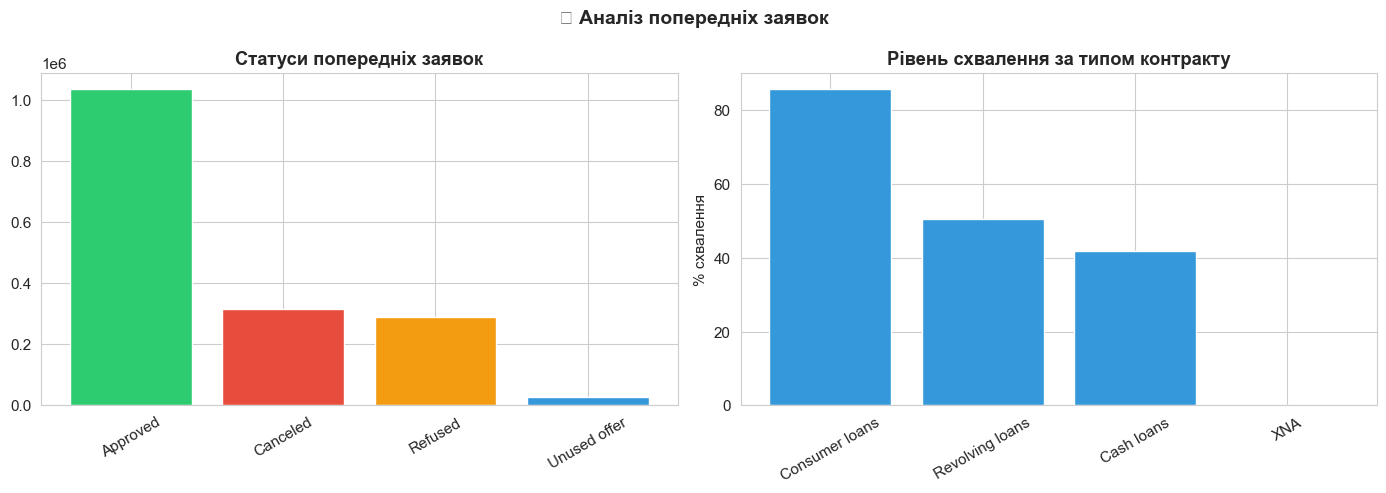

In [17]:
# Previous Applications
prev = load_local('previous_application')
prev.columns = [c.lower() for c in prev.columns]

print(f'Previous application: {prev.shape[0]:,} рядків')
print(f'Унікальних клієнтів: {prev["sk_id_curr"].nunique():,}')

# Статус попередніх заявок
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts = prev['name_contract_status'].value_counts()
colors_status = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6']
axes[0].bar(status_counts.index, status_counts.values,
            color=colors_status[:len(status_counts)])
axes[0].set_title('Статуси попередніх заявок', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Approval rate by contract type
approval = prev.groupby('name_contract_type').apply(
    lambda x: (x['name_contract_status'] == 'Approved').sum() / len(x) * 100
).sort_values(ascending=False)
axes[1].bar(approval.index, approval.values, color='#3498db')
axes[1].set_title('Рівень схвалення за типом контракту', fontweight='bold')
axes[1].set_ylabel('% схвалення')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('📋 Аналіз попередніх заявок', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plots/prev_app_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Висновки EDA

In [18]:
print('=' * 60)
print('  📊 ВИСНОВКИ РОЗВІДУВАЛЬНОГО АНАЛІЗУ')
print('=' * 60)
print()
print('🎯 ЦІЛЬОВА ЗМІННА:')
print(f'  - Рівень дефолту: ~8% (сильний дисбаланс класів)')
print(f'  - Необхідна стратегія: SMOTE, class_weight або threshold tuning')
print()
print('💡 НАЙВАЖЛИВІШІ ОЗНАКИ (очікується):')
print('  1. EXT_SOURCE_1/2/3 — зовнішній скоринг (найсильніший сигнал)')
print('  2. DAYS_BIRTH (вік) — молодші клієнти ризикованіші')
print('  3. AMT_CREDIT / AMT_INCOME_TOTAL — боргове навантаження')
print('  4. DAYS_EMPLOYED — стаж роботи')
print('  5. Агрегати з bureau — кредитна історія')
print()
print('⚠️ ПРОБЛЕМИ:')
print('  - Багато пропущених значень (деякі колонки >50%)')
print('  - Аномальне значення DAYS_EMPLOYED = 365243 (пенсіонери)')
print('  - XNA у категоріальних ознаках')
print()
print('✅ ПЛАН ПОБУДОВИ МОДЕЛІ:')
print('  1. Feature engineering з 7 таблиць')
print('  2. Медіанна імпутація числових + OrdinalEncoder категоріальних')
print('  3. LightGBM з class_weight="balanced"')
print('  4. 5-fold StratifiedKFold CV')
print('  5. Метрика: ROC-AUC')

  📊 ВИСНОВКИ РОЗВІДУВАЛЬНОГО АНАЛІЗУ

🎯 ЦІЛЬОВА ЗМІННА:
  - Рівень дефолту: ~8% (сильний дисбаланс класів)
  - Необхідна стратегія: SMOTE, class_weight або threshold tuning

💡 НАЙВАЖЛИВІШІ ОЗНАКИ (очікується):
  1. EXT_SOURCE_1/2/3 — зовнішній скоринг (найсильніший сигнал)
  2. DAYS_BIRTH (вік) — молодші клієнти ризикованіші
  3. AMT_CREDIT / AMT_INCOME_TOTAL — боргове навантаження
  4. DAYS_EMPLOYED — стаж роботи
  5. Агрегати з bureau — кредитна історія

⚠️ ПРОБЛЕМИ:
  - Багато пропущених значень (деякі колонки >50%)
  - Аномальне значення DAYS_EMPLOYED = 365243 (пенсіонери)
  - XNA у категоріальних ознаках

✅ ПЛАН ПОБУДОВИ МОДЕЛІ:
  1. Feature engineering з 7 таблиць
  2. Медіанна імпутація числових + OrdinalEncoder категоріальних
  3. LightGBM з class_weight="balanced"
  4. 5-fold StratifiedKFold CV
  5. Метрика: ROC-AUC
